<a href="https://colab.research.google.com/github/fernandodeeke/epidemy/blob/main/sir_basic_disc_est.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated beta:  0.9761
Estimated gamma: 0.5559
Estimated $R_0$: 1.7560


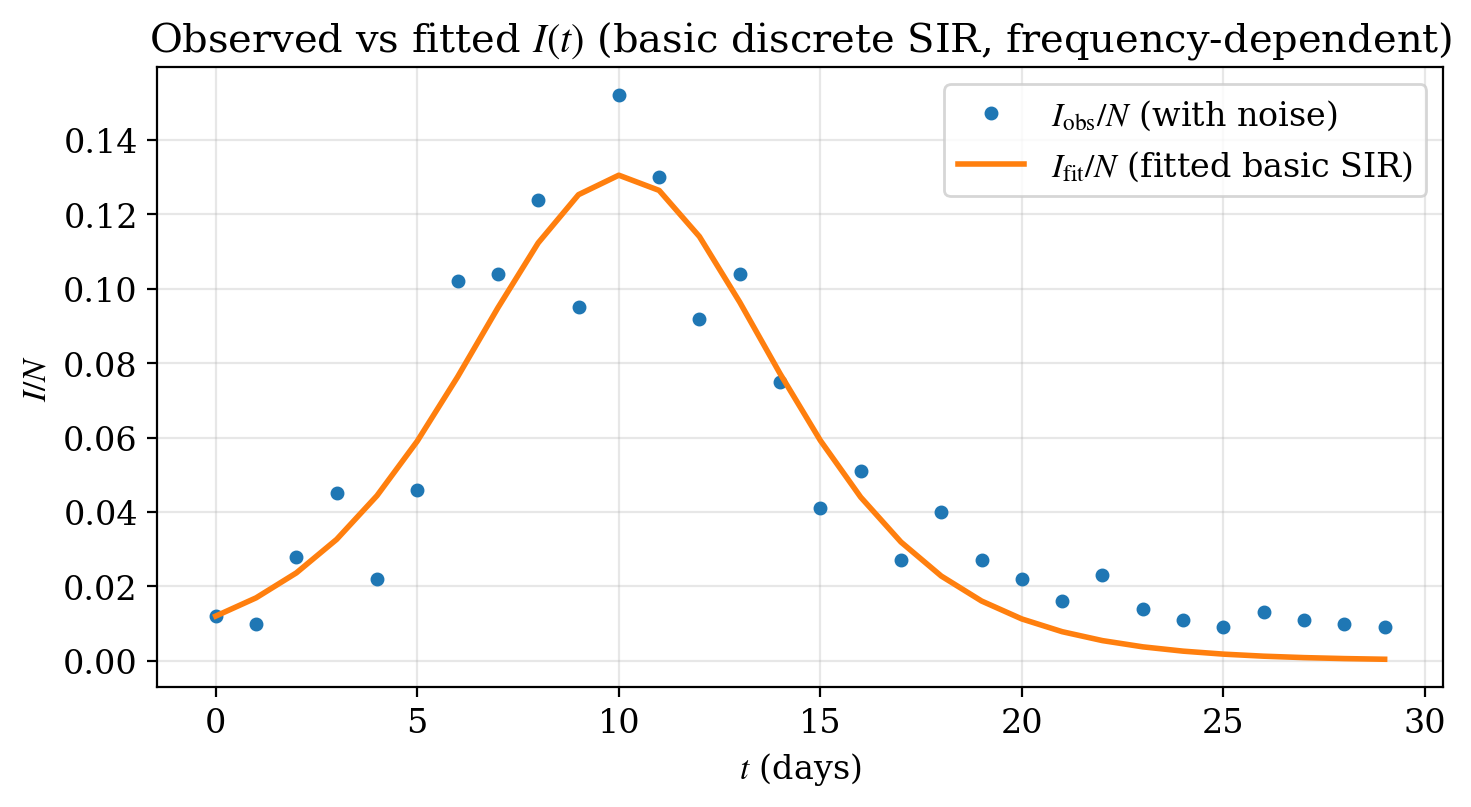

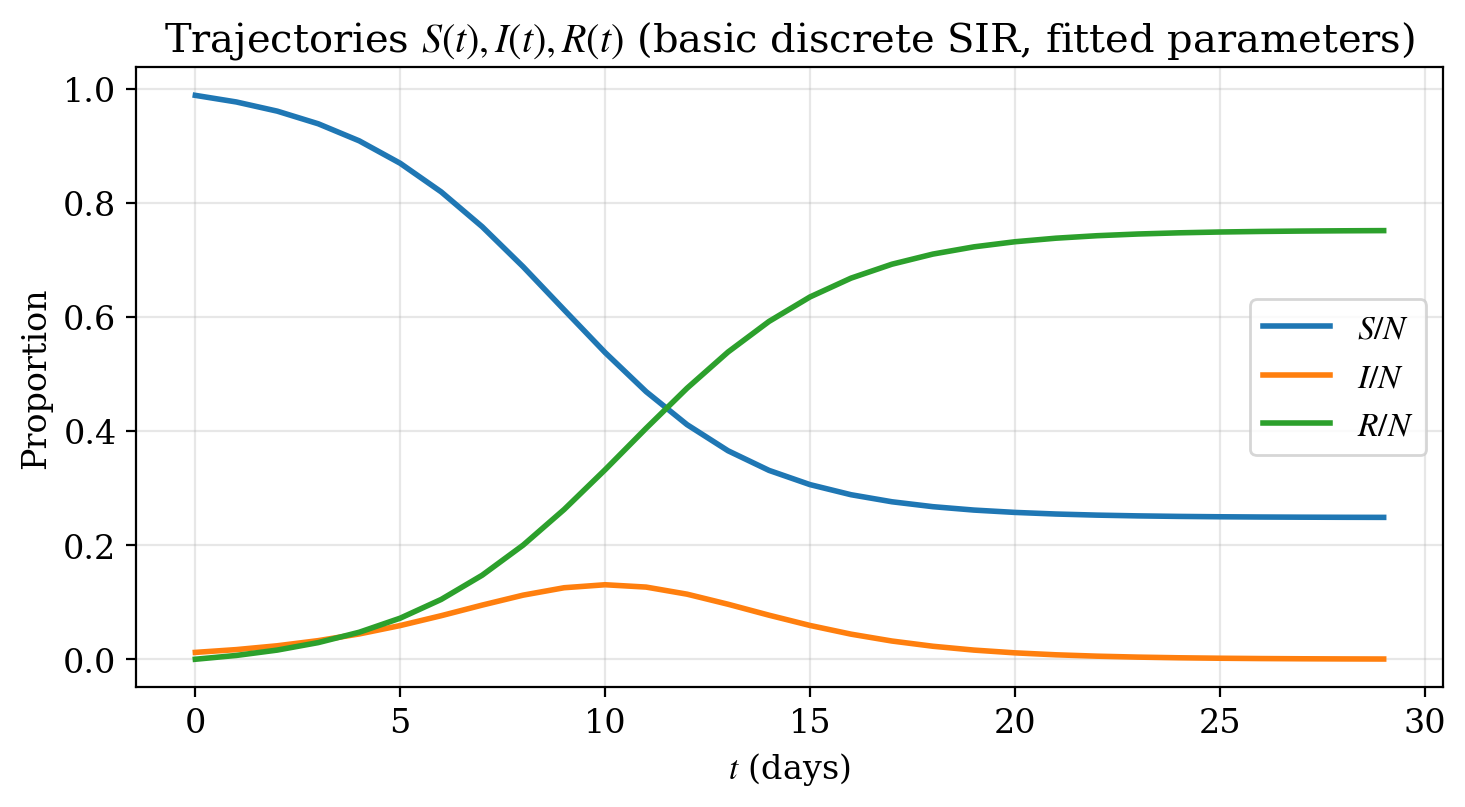

In [ ]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 12,
})

# ============================================================
# PARAMETER FITTING IN THE BASIC DISCRETE SIR MODEL (EULER)
# Frequency-dependent transmission (incidence ~ S*I/N)
#
# Daily update (Dt = 1):
#   S[t+1] = S[t] - beta  * S[t] * I[t] / N
#   I[t+1] = I[t] + (beta * S[t] * I[t] / N - gamma * I[t])
#   R[t+1] = R[t] + gamma * I[t]
#
# Goal: estimate (beta, gamma) from observations of I(t),
# by minimizing the sum of squared errors
# ============================================================


def sir_basic(params, S0, I0, R0, N, days):
    """
    Simulates the basic discrete SIR model (daily step) and returns only I(t),
    since the fit uses only the observed infected time series.

    params = (beta, gamma)
    S0, I0, R0: initial conditions
    N: total population (constant)
    days: number of points (e.g., len(I_obs))
    """
    beta, gamma = params

    # Arrays to store the trajectory (float values, even if they represent counts)
    S = np.zeros(days, dtype=float)
    I = np.zeros(days, dtype=float)
    R = np.zeros(days, dtype=float)

    # Initial state
    S[0], I[0], R[0] = S0, I0, R0

    # Discrete-time iteration
    for t in range(days - 1):
        S[t + 1] = S[t] - beta * S[t] * I[t] / N
        I[t + 1] = I[t] + (beta * S[t] * I[t] / N - gamma * I[t])
        R[t + 1] = R[t] + gamma * I[t]

        # Minimal correction: prevents negative I values due to numerical effects
        if I[t + 1] < 0:
            I[t + 1] = 0.0

    # For fitting, return only the predicted infected series
    return I


def sir_basic_full(params, S0, I0, R0, N, days):
    """
    Same simulation as sir_basic, but returns (S, I, R).
    Useful for plotting trajectories after estimating parameters.
    """
    beta, gamma = params

    S = np.zeros(days, dtype=float)
    I = np.zeros(days, dtype=float)
    R = np.zeros(days, dtype=float)

    S[0], I[0], R[0] = S0, I0, R0

    for t in range(days - 1):
        S[t + 1] = S[t] - beta * S[t] * I[t] / N
        I[t + 1] = I[t] + (beta * S[t] * I[t] / N - gamma * I[t])
        R[t + 1] = R[t] + gamma * I[t]

        if I[t + 1] < 0:
            I[t + 1] = 0.0

    return S, I, R


# Objective function for least squares
def objective(params, I_obs, S0, I0, R0, N):
    I_pred = sir_basic(params, S0, I0, R0, N, len(I_obs))
    return np.sum((I_pred - I_obs) ** 2)


# Baseline series + noise (to mimic real data)
I_b = np.array([
    10, 15, 23, 35, 52, 75, 98, 115, 125, 128, 120, 105,
    90, 78, 66, 55, 46, 38, 32, 27, 23, 20, 17, 15,
    13, 11, 10, 9, 8, 7
])

# Total population (constant in the model)
N = 1000

# Pseudorandom generator with a fixed seed (reproducibility)
rng = np.random.default_rng(42)

# Heteroscedastic noise: variance grows with I
noise_frac = 0.30
noise_sd = np.maximum(5, noise_frac * I_b)  # minimum SD of 5

# Observed series: add noise and round to integer counts
I_obs = np.rint(I_b + rng.normal(0.0, noise_sd)).astype(int)
I_obs = np.clip(I_obs, 0, N)

# Initial conditions consistent with day 0
S0, I0, R0 = N - I_obs[0], I_obs[0], 0

# Time axis (days)
t = np.arange(len(I_obs))


# -------------------------------------------------------------------
# OPTIMIZATION: estimate beta and gamma by least squares
# -------------------------------------------------------------------
initial_guess = [0.5, 0.1]

result = minimize(
    objective, initial_guess,
    args=(I_obs, S0, I0, R0, N),
    bounds=[(0, 2), (0, 1)]
)

beta_est, gamma_est = result.x
R0_est = beta_est / gamma_est if gamma_est > 0 else np.inf

print(f"Estimated beta:  {beta_est:.4f}")
print(f"Estimated gamma: {gamma_est:.4f}")
print(f"Estimated $R_0$: {R0_est:.4f}")


# -------------------------------------------------------------------
# 1) PLOT: observed I vs fitted I
# -------------------------------------------------------------------
I_est = sir_basic([beta_est, gamma_est], S0, I0, R0, N, len(I_obs))

plt.figure(figsize=(7.5, 4.2), dpi=200)
plt.plot(t, I_obs / N, "o", label=r"$I_{\mathrm{obs}}/N$ (with noise)", markersize=4)
plt.plot(t, I_est / N, "-", label=r"$I_{\mathrm{fit}}/N$ (fitted basic SIR)", linewidth=2)
plt.title(r"Observed vs fitted $I(t)$ (basic discrete SIR, frequency-dependent)")
plt.xlabel(r"$t$ (days)")
plt.ylabel(r"$I/N$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# High-resolution outputs (raster + vector)
plt.savefig("sir_basic_fit_I.png", dpi=600, bbox_inches="tight")
plt.savefig("sir_basic_fit_I.pdf", bbox_inches="tight")
plt.show()


# -------------------------------------------------------------------
# 2) PLOT: S, I, R trajectories with estimated parameters
# -------------------------------------------------------------------
S_fit, I_fit, R_fit = sir_basic_full([beta_est, gamma_est], S0, I0, R0, N, len(I_obs))

plt.figure(figsize=(7.5, 4.2), dpi=200)
plt.plot(t, S_fit / N, label=r"$S/N$", linewidth=2)
plt.plot(t, I_fit / N, label=r"$I/N$", linewidth=2)
plt.plot(t, R_fit / N, label=r"$R/N$", linewidth=2)
plt.title(r"Trajectories $S(t), I(t), R(t)$ (basic discrete SIR, fitted parameters)")
plt.xlabel(r"$t$ (days)")
plt.ylabel(r"Proportion")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("sir_basic_fit_SIR.png", dpi=600, bbox_inches="tight")
plt.savefig("sir_basic_fit_SIR.pdf", bbox_inches="tight")
plt.show()